# Water-Sensor Data Cleaning Pipeline

This notebook assumes that the original sensor dataset has already been imported as a pandas dataframe named `df`.

The pipeline is intentionally conservative:

- known error/sentinel codes are removed;
- only clearly impossible or technically invalid values are removed automatically;
- duplicate sensor timestamps are consolidated;
- all operations use the actual timestamp order;
- statistical anomalies are **flagged**, not automatically deleted;
- oxygen problems do not automatically erase valid conductivity, ORP, or turbidity values;
- no interpolation is performed by default;
- the final modelling dataset requires only the four variables currently used by the water-quality system.

The notebook produces:

- `df_clean`: all retained rows, cleaned measurements, and diagnostic flags;
- `df_model`: complete rows for the four modelling features;
- `df_model_strict`: an optional stricter version excluding flagged anomalies;
- audit tables showing exactly how much data each rule affected.

> **Important unit check:** the conductivity column is named `mS_cm`, but values near 50,000 may indicate that the actual unit is `µS/cm`. Confirm the sensor documentation before displaying units on the website.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from funcs import plot_sensors


pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [3]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\water_stats.csv")

## 1. Configuration

The limits below should be treated as configurable technical screening limits, not official environmental-quality thresholds.

The four `MODEL_FEATURES` are the measurements currently used for clustering and status scoring. Temperature is retained as an auxiliary diagnostic variable but does not determine whether a row is available for the model.


In [4]:
SENSOR_COL = "sensor_id"
TIME_COL = "date_insert"

TEMPERATURE_COL = "wtempV_°C"
CONDUCTIVITY_COL = "conductivity_of_solution_ mS_cm"
ORP_COL = "oxidation_reduction_potential_ mV"
TURBIDITY_COL = "turbidity_NTU"
OXYGEN_COL = "oxygen_saturation_%"

MODEL_FEATURES = [
    CONDUCTIVITY_COL,
    ORP_COL,
    OXYGEN_COL,
    TURBIDITY_COL,
]

AUXILIARY_FEATURES = [
    TEMPERATURE_COL,
]

CLEANED_FEATURES = AUXILIARY_FEATURES + MODEL_FEATURES

REGIONS = {
    976: "Ακταίο",
    977: "Ψαθόπυργος",
    978: "Αραχωβίτικα",
    979: "Άγιος Βασίλης",
    980: "Ρίο",
    981: "Καστελλόκαμπος",
    982: "Δάφνες",
    983: "Πλάζ",
    984: "Ροιτικά",
}

# Exact known error codes. Add any additional documented codes here.
SENTINEL_VALUES = [
    9998.01,
    9999.01,
    9999.0,
    -999.0,
    9998.04,
    9991.04
]

# Conservative hard limits used only to reject clearly invalid readings.
# Review these against the actual sensor specifications.
HARD_LIMITS = {
    TEMPERATURE_COL: (0.0, 45.0),
    CONDUCTIVITY_COL: (0.0, 100_000.0),
    ORP_COL: (-1_000.0, 1_000.0),
    TURBIDITY_COL: (0.0, 1_000.0),
    OXYGEN_COL: (0.0, 200.0),
}

# Parameters used only to FLAG unusual observations.
ROLLING_WINDOW = "48h"
ROLLING_MIN_OBSERVATIONS = 8
ROBUST_Z_THRESHOLD = 8.0

# A point must exceed both the robust-z threshold and this absolute deviation
# before it is flagged. These values do not automatically delete anything.
MIN_ABSOLUTE_DEVIATION = {
    TEMPERATURE_COL: 2.0,
    CONDUCTIVITY_COL: 5_000.0,
    ORP_COL: 150.0,
    TURBIDITY_COL: 100.0,
    OXYGEN_COL: 30.0,
}

# Diagnostic oxygen flags. These are not automatically treated as proof
# that the whole sensor row is invalid.
OXYGEN_LOW_24H_THRESHOLD = 10.0
OXYGEN_NOISY_24H_STD_THRESHOLD = 25.0
OXYGEN_DRIFT_LEVEL_THRESHOLD = 55.0
OXYGEN_DRIFT_CHANGE_THRESHOLD = -2.0

# Used only when plotting, so lines are not drawn across long missing periods.
PLOT_GAP_THRESHOLD = pd.Timedelta("24h")


## 2. Validate and preserve the original dataframe

The original dataframe is copied to `df_raw` and is never modified. All cleaning happens in `df_clean`.


In [5]:
if "df" not in globals():
    raise NameError(
        "This notebook expects the original dataset to already exist as a dataframe named 'df'."
    )

required_columns = [SENSOR_COL, TIME_COL] + CLEANED_FEATURES
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise KeyError(
        f"The dataframe is missing the following required columns: {missing_columns}"
    )

df_raw = df.copy(deep=True)
df_clean = df.copy(deep=True)

print(f"Original rows: {len(df_raw):,}")
print(f"Sensors: {df_raw[SENSOR_COL].nunique()}")
display(df_raw.head())


Original rows: 34,146
Sensors: 9


,id,date_insert,year,month,day,hour,sensor_id,lat,lng,wtempV_°C,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,total_suspended_solids_mg_L,turbidity_NTU,dissolved_oxygen_concentration _ppm,dissolved_oxygen_concentration_mg_L,oxygen_saturation_%,salinity_ppt,dissolved_solids _ppm
0,1,2025-07-03 14:00:00,2025,7,3,14,976,38.310409,21.784038,24.88,53426.82,NaN,61.81,NaN,7.84,7.84,94.68,NaN,NaN
1,2,2025-07-03 14:00:00,2025,7,3,14,983,38.282368,21.754868,NaN,16356.51,NaN,21.92,NaN,NaN,8.85,NaN,NaN,NaN
2,3,2025-07-03 15:00:00,2025,7,3,15,976,38.310409,21.784038,24.96,56828.55,-170.59,63.73,80.74,7.91,7.91,95.62,37.99,37057.90
3,4,2025-07-03 15:00:00,2025,7,3,15,977,38.328212,21.876467,25.18,55496.83,-164.88,171.17,106.32,8.16,8.16,99.18,36.93,36189.48
4,5,2025-07-03 15:00:00,2025,7,3,15,978,38.331904,21.842924,23.61,56486.60,-42.81,37.69,20.70,9.18,9.18,108.31,37.72,36834.91


## 3. Standardize timestamps, numeric columns, and ordering

Unlike the earlier pipeline, this notebook explicitly sorts by `date_insert`. Time-based diagnostics therefore refer to real hours and days rather than an assumed number of observations.


In [6]:
df_clean[TIME_COL] = pd.to_datetime(
    df_clean[TIME_COL],
    errors="coerce",
)

for column in CLEANED_FEATURES:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce",
    )

invalid_timestamp_mask = df_clean[TIME_COL].isna()
invalid_timestamp_rows = int(invalid_timestamp_mask.sum())

if invalid_timestamp_rows:
    print(f"Removing {invalid_timestamp_rows:,} rows with invalid timestamps.")
    df_clean = df_clean.loc[~invalid_timestamp_mask].copy()

if "location" not in df_clean.columns:
    df_clean["location"] = df_clean[SENSOR_COL].map(REGIONS)

df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_clean["_source_row_id"] = np.arange(len(df_clean))

print(f"Rows after timestamp validation: {len(df_clean):,}")


Rows after timestamp validation: 34,146


## 4. Remove exact duplicates and consolidate duplicate timestamps

Exact duplicate rows are removed first. If the same sensor has several different rows at the same timestamp, numeric measurements are combined using their median and non-numeric metadata use the first non-missing value.

A median is less sensitive than a mean to one corrupted duplicate.


In [7]:
rows_before_duplicates = len(df_clean)

exact_duplicate_mask = df_clean.duplicated(keep="first")
exact_duplicates_removed = int(exact_duplicate_mask.sum())
df_clean = df_clean.loc[~exact_duplicate_mask].copy()

duplicate_timestamp_mask = df_clean.duplicated(
    subset=[SENSOR_COL, TIME_COL],
    keep=False,
)

duplicate_timestamp_rows = int(duplicate_timestamp_mask.sum())
duplicate_timestamp_groups = int(
    df_clean.loc[duplicate_timestamp_mask, [SENSOR_COL, TIME_COL]]
    .drop_duplicates()
    .shape[0]
)

numeric_columns = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [
    column
    for column in numeric_columns
    if column not in [SENSOR_COL, "_source_row_id"]
]

non_numeric_columns = [
    column
    for column in df_clean.columns
    if column not in numeric_columns + [SENSOR_COL, TIME_COL]
]

aggregation_rules = {
    column: "median"
    for column in numeric_columns
}
aggregation_rules.update({
    column: "first"
    for column in non_numeric_columns
})

df_clean = (
    df_clean
    .groupby([SENSOR_COL, TIME_COL], as_index=False, sort=False)
    .agg(aggregation_rules)
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_clean["_row_id"] = np.arange(len(df_clean))

print(f"Exact duplicate rows removed: {exact_duplicates_removed:,}")
print(f"Duplicate sensor-timestamp groups consolidated: {duplicate_timestamp_groups:,}")
print(f"Rows involved in duplicated timestamps: {duplicate_timestamp_rows:,}")
print(f"Rows after duplicate handling: {len(df_clean):,}")


Exact duplicate rows removed: 0
Duplicate sensor-timestamp groups consolidated: 0
Rows involved in duplicated timestamps: 0
Rows after duplicate handling: 34,146


## 5. Replace known sentinel values

Only exact documented error codes are replaced. We do **not** use a general rule such as “remove every value near 10,000,” because conductivity can legitimately have much larger numerical values.


In [8]:
sentinel_audit_records = []

for column in CLEANED_FEATURES:
    original_values = df_clean[column].copy()
    sentinel_mask = pd.Series(False, index=df_clean.index)

    for sentinel in SENTINEL_VALUES:
        sentinel_mask |= np.isclose(
            original_values,
            sentinel,
            rtol=0.0,
            atol=1e-6,
            equal_nan=False,
        )

    df_clean[f"{column}__sentinel_invalid"] = sentinel_mask
    df_clean.loc[sentinel_mask, column] = np.nan

    sentinel_audit_records.append({
        "feature": column,
        "sentinel_values_removed": int(sentinel_mask.sum()),
    })

sentinel_audit = pd.DataFrame(sentinel_audit_records)
display(sentinel_audit)


,feature,sentinel_values_removed
0,wtempV_°C,0
1,conductivity_of_solution_ mS_cm,501
2,oxidation_reduction_potential_ mV,0
3,oxygen_saturation_%,114
4,turbidity_NTU,0


## 6. Apply conservative hard limits

Values outside the configured hard limits are set to missing. A separate Boolean column records which rule affected each observation.


In [9]:
hard_limit_audit_records = []

for column, (lower_limit, upper_limit) in HARD_LIMITS.items():
    invalid_mask = (
        df_clean[column].notna()
        & (
            (df_clean[column] < lower_limit)
            | (df_clean[column] > upper_limit)
        )
    )

    df_clean[f"{column}__hard_limit_invalid"] = invalid_mask
    df_clean.loc[invalid_mask, column] = np.nan

    hard_limit_audit_records.append({
        "feature": column,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit,
        "hard_limit_values_removed": int(invalid_mask.sum()),
    })

hard_limit_audit = pd.DataFrame(hard_limit_audit_records)
display(hard_limit_audit)


,feature,lower_limit,upper_limit,hard_limit_values_removed
0,wtempV_°C,0.0,45.0,0
1,conductivity_of_solution_ mS_cm,0.0,100000.0,7
2,oxidation_reduction_potential_ mV,-1000.0,1000.0,3
3,turbidity_NTU,0.0,1000.0,1360
4,oxygen_saturation_%,0.0,200.0,759


## 6.5. Detect persistent near-zero oxygen periods

Hourly oxygen measurements below 1% are treated as a likely sensor failure only when they persist for at least 12 readings over approximately 11 hours. Only the oxygen value is invalidated; the remaining measurements are preserved.

In [10]:
# ------------------------------------------------------------
# Detect persistent near-zero oxygen failure periods
# ------------------------------------------------------------

OXYGEN_FAILURE_THRESHOLD = 1.0

# Because the original measurements are hourly:
MIN_LOW_OXYGEN_READINGS = 12

# Twelve hourly readings span approximately eleven hours
# from the first timestamp to the last timestamp.
MIN_LOW_OXYGEN_DURATION = pd.Timedelta("11h")

# Allow one missing hourly reading without joining observations
# that are far apart.
MAX_ALLOWED_GAP = pd.Timedelta("2h")


# Ensure correct chronological order before detecting sequences.
df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)


# Flag every individual oxygen value below 1%.
df_clean["oxygen_below_1_flag"] = (
    df_clean[OXYGEN_COL].notna()
    & (df_clean[OXYGEN_COL] < OXYGEN_FAILURE_THRESHOLD)
)


# Time difference from the previous observation of the same sensor.
oxygen_time_gap = (
    df_clean
    .groupby(SENSOR_COL)[TIME_COL]
    .diff()
)


# Whether the previous observation for the same sensor
# was also below 1%.
previous_was_low = (
    df_clean
    .groupby(SENSOR_COL)["oxygen_below_1_flag"]
    .shift(fill_value=False)
)


# A new low-oxygen sequence starts when:
# 1. the current value is below 1%, and
# 2. the previous value was not below 1%, or
# 3. the time gap from the previous reading is too large.
new_low_sequence = (
    df_clean["oxygen_below_1_flag"]
    & (
        ~previous_was_low
        | oxygen_time_gap.gt(MAX_ALLOWED_GAP)
    )
)


# Assign a sequence number separately inside each sensor.
df_clean["oxygen_low_sequence_id"] = (
    new_low_sequence
    .groupby(df_clean[SENSOR_COL])
    .cumsum()
    .where(df_clean["oxygen_below_1_flag"])
)


# Number of readings in each near-zero sequence.
df_clean["oxygen_low_sequence_readings"] = (
    df_clean
    .groupby(
        [SENSOR_COL, "oxygen_low_sequence_id"]
    )[OXYGEN_COL]
    .transform("size")
    .where(df_clean["oxygen_below_1_flag"])
)


# Beginning and end of every near-zero sequence.
sequence_start = (
    df_clean
    .groupby(
        [SENSOR_COL, "oxygen_low_sequence_id"]
    )[TIME_COL]
    .transform("min")
)

sequence_end = (
    df_clean
    .groupby(
        [SENSOR_COL, "oxygen_low_sequence_id"]
    )[TIME_COL]
    .transform("max")
)

df_clean["oxygen_low_sequence_duration"] = (
    sequence_end - sequence_start
).where(df_clean["oxygen_below_1_flag"])


# A sequence is treated as a likely oxygen-channel failure only
# when it is sufficiently long and persistent.
df_clean["oxygen_persistent_near_zero"] = (
    df_clean["oxygen_below_1_flag"]
    & (
        df_clean["oxygen_low_sequence_readings"]
        >= MIN_LOW_OXYGEN_READINGS
    )
    & (
        df_clean["oxygen_low_sequence_duration"]
        >= MIN_LOW_OXYGEN_DURATION
    )
)


print(
    "Individual oxygen readings below 1%:",
    int(df_clean["oxygen_below_1_flag"].sum())
)

print(
    "Readings inside persistent near-zero periods:",
    int(df_clean["oxygen_persistent_near_zero"].sum())
)


# Preserve the original value for auditing.
df_clean["oxygen_saturation_original"] = df_clean[OXYGEN_COL]


# Invalidate only oxygen during likely failure periods.
# Conductivity, ORP and turbidity remain available.
df_clean.loc[
    df_clean["oxygen_persistent_near_zero"],
    OXYGEN_COL
] = np.nan

Individual oxygen readings below 1%: 11062
Readings inside persistent near-zero periods: 9850


## 6.6. Review detected oxygen-failure intervals

This table shows the sensor, start time, end time, duration, and number of readings for every detected near-zero oxygen period.

In [11]:
oxygen_failure_intervals = (
    df_clean.loc[
        df_clean["oxygen_persistent_near_zero"]
    ]
    .groupby(
        [SENSOR_COL, "oxygen_low_sequence_id"],
        as_index=False
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=("oxygen_saturation_original", "size"),
        minimum_oxygen=("oxygen_saturation_original", "min"),
        maximum_oxygen=("oxygen_saturation_original", "max"),
    )
)

oxygen_failure_intervals["duration_hours"] = (
    oxygen_failure_intervals["end_time"]
    - oxygen_failure_intervals["start_time"]
).dt.total_seconds() / 3600

display(oxygen_failure_intervals)

,sensor_id,oxygen_low_sequence_id,start_time,end_time,readings,minimum_oxygen,maximum_oxygen,duration_hours
0,976,20.0,2025-09-08 12:00:00,2025-09-10 09:00:00,46,0.0,0.0,45.0
1,976,21.0,2025-09-15 09:00:00,2025-09-25 15:00:00,247,0.0,0.0,246.0
2,976,22.0,2025-09-25 23:00:00,2025-10-02 13:00:00,159,0.0,0.0,158.0
3,976,26.0,2025-10-11 12:00:00,2025-10-13 09:00:00,46,0.0,0.0,45.0
4,976,37.0,2025-11-03 11:00:00,2025-11-03 22:00:00,12,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...
61,984,75.0,2025-12-22 07:00:00,2025-12-23 00:00:00,18,0.0,0.0,17.0
62,984,77.0,2025-12-23 17:00:00,2025-12-26 14:00:00,70,0.0,0.0,69.0
63,984,78.0,2025-12-26 16:00:00,2025-12-28 11:00:00,44,0.0,0.0,43.0
64,984,91.0,2025-12-30 15:00:00,2026-01-01 14:00:00,48,0.0,0.0,47.0


## 6.7. Detect short conductivity drop-and-recovery glitches

A conductivity value is treated as a likely temporary measurement glitch only when it drops sharply relative to the sensor's preceding 24-hour baseline, lasts no more than three hourly readings, and quickly returns close to its previous level.

Longer conductivity changes are retained because they may represent real environmental changes or persistent sensor problems. Only conductivity is invalidated; the other measurements remain available.

In [12]:
# ------------------------------------------------------------
# Detect short conductivity drop-and-recovery glitches
# ------------------------------------------------------------

# Current value must be at most 35% of the previous 24-hour median.
# This represents a drop of at least 65%.
CONDUCTIVITY_DROP_RATIO = 0.35

# Previous and next values must recover to at least 75%
# of the preceding baseline.
CONDUCTIVITY_RECOVERY_RATIO = 0.75

# Avoid applying the rule when the sensor's normal conductivity
# is already relatively low.
MIN_CONDUCTIVITY_BASELINE = 20_000

# The absolute decrease must also be substantial.
MIN_CONDUCTIVITY_DROP = 10_000

# Measurements are hourly, so treat sequences of at most
# three readings as short transient events.
MAX_TRANSIENT_READINGS = 3

# Consecutive hourly measurements may occasionally be slightly delayed.
MAX_SEQUENCE_GAP = pd.Timedelta("2h")

# Require a recovery reading reasonably soon after the suspected drop.
MAX_RECOVERY_GAP = pd.Timedelta("4h")


def detect_transient_conductivity_drops(sensor_df):
    """
    Flag brief conductivity collapses that quickly return
    to the preceding baseline.
    """

    sensor_df = (
        sensor_df
        .sort_values(TIME_COL)
        .copy()
    )

    # Use the preceding 24 hours as the local conductivity baseline.
    # shift(1) ensures the current observation is not used
    # to calculate its own baseline.
    time_indexed = sensor_df.set_index(TIME_COL)

    baseline = (
        time_indexed[CONDUCTIVITY_COL]
        .rolling(
            "24h",
            min_periods=12
        )
        .median()
        .shift(1)
    )

    # Restore alignment with sensor_df.
    baseline = baseline.to_numpy()

    sensor_df["conductivity_baseline_24h"] = baseline

    conductivity_drop = (
        sensor_df["conductivity_baseline_24h"]
        - sensor_df[CONDUCTIVITY_COL]
    )

    # Initial candidates are large relative and absolute drops.
    candidate_drop = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df["conductivity_baseline_24h"].notna()
        & (
            sensor_df["conductivity_baseline_24h"]
            >= MIN_CONDUCTIVITY_BASELINE
        )
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= (
                CONDUCTIVITY_DROP_RATIO
                * sensor_df["conductivity_baseline_24h"]
            )
        )
        & (
            conductivity_drop
            >= MIN_CONDUCTIVITY_DROP
        )
    )

    sensor_df["conductivity_drop_candidate"] = candidate_drop

    time_gap = sensor_df[TIME_COL].diff()

    previous_was_candidate = (
        candidate_drop.shift(fill_value=False)
    )

    new_sequence = (
        candidate_drop
        & (
            ~previous_was_candidate
            | time_gap.gt(MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = (
        new_sequence
        .cumsum()
        .where(candidate_drop)
    )

    sensor_df["conductivity_drop_sequence_id"] = sequence_id
    sensor_df["conductivity_transient_glitch"] = False

    sequence_ids = (
        sequence_id
        .dropna()
        .unique()
    )

    for current_sequence_id in sequence_ids:

        sequence_positions = np.flatnonzero(
            sequence_id.eq(current_sequence_id).to_numpy()
        )

        number_of_readings = len(sequence_positions)

        # Persistent changes are deliberately not automatically removed.
        if number_of_readings > MAX_TRANSIENT_READINGS:
            continue

        first_position = sequence_positions[0]
        last_position = sequence_positions[-1]

        previous_position = first_position - 1
        next_position = last_position + 1

        # A drop cannot be confirmed as transient without values
        # immediately before and after it.
        if (
            previous_position < 0
            or next_position >= len(sensor_df)
        ):
            continue

        sequence_start = sensor_df.iloc[first_position][TIME_COL]
        sequence_end = sensor_df.iloc[last_position][TIME_COL]

        previous_time = sensor_df.iloc[previous_position][TIME_COL]
        next_time = sensor_df.iloc[next_position][TIME_COL]

        gap_before = sequence_start - previous_time
        gap_after = next_time - sequence_end

        if gap_before > MAX_SEQUENCE_GAP:
            continue

        if gap_after > MAX_RECOVERY_GAP:
            continue

        baseline_at_start = sensor_df.iloc[
            first_position
        ]["conductivity_baseline_24h"]

        previous_value = sensor_df.iloc[
            previous_position
        ][CONDUCTIVITY_COL]

        next_value = sensor_df.iloc[
            next_position
        ][CONDUCTIVITY_COL]

        if (
            pd.isna(baseline_at_start)
            or pd.isna(previous_value)
            or pd.isna(next_value)
        ):
            continue

        previous_is_normal = (
            previous_value
            >= CONDUCTIVITY_RECOVERY_RATIO * baseline_at_start
        )

        next_is_recovered = (
            next_value
            >= CONDUCTIVITY_RECOVERY_RATIO * baseline_at_start
        )

        if previous_is_normal and next_is_recovered:
            sensor_df.iloc[
                sequence_positions,
                sensor_df.columns.get_loc(
                    "conductivity_transient_glitch"
                )
            ] = True

    return sensor_df


# Ensure the rows are in the correct hourly sequence.
df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)


# Preserve the original conductivity for auditing.
if "conductivity_original" not in df_clean.columns:
    df_clean["conductivity_original"] = (
        df_clean[CONDUCTIVITY_COL]
    )


df_clean = (
    df_clean
    .groupby(
        SENSOR_COL,
        group_keys=False
    )
    .apply(
        detect_transient_conductivity_drops
    )
    .reset_index(drop=True)
)


print(
    "Conductivity readings identified as transient glitches:",
    int(
        df_clean[
            "conductivity_transient_glitch"
        ].sum()
    )
)


# Invalidate only conductivity.
# ORP, oxygen and turbidity remain untouched in df_clean.
df_clean.loc[
    df_clean["conductivity_transient_glitch"],
    CONDUCTIVITY_COL
] = np.nan

Conductivity readings identified as transient glitches: 64


C:\Users\User\AppData\Local\Temp\ipykernel_20292\74370888.py:222: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


## 6.8. Review detected conductivity glitches

This table lists short conductivity collapses that were removed because the readings quickly returned near their preceding 24-hour baseline. Longer changes remain in the dataset for review.

In [13]:
conductivity_glitch_intervals = (
    df_clean.loc[
        df_clean["conductivity_transient_glitch"]
    ]
    .groupby(
        [
            SENSOR_COL,
            "conductivity_drop_sequence_id"
        ],
        as_index=False
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=("conductivity_original", "size"),
        baseline_conductivity=(
            "conductivity_baseline_24h",
            "median"
        ),
        minimum_conductivity=(
            "conductivity_original",
            "min"
        ),
        maximum_conductivity=(
            "conductivity_original",
            "max"
        ),
    )
)

conductivity_glitch_intervals["duration_hours"] = (
    (
        conductivity_glitch_intervals["end_time"]
        - conductivity_glitch_intervals["start_time"]
    )
    .dt.total_seconds()
    / 3600
)

conductivity_glitch_intervals["percentage_drop"] = (
    100
    * (
        conductivity_glitch_intervals[
            "baseline_conductivity"
        ]
        - conductivity_glitch_intervals[
            "minimum_conductivity"
        ]
    )
    / conductivity_glitch_intervals[
        "baseline_conductivity"
    ]
)

display(
    conductivity_glitch_intervals.sort_values(
        [SENSOR_COL, "start_time"]
    )
)

,sensor_id,conductivity_drop_sequence_id,start_time,end_time,readings,baseline_conductivity,minimum_conductivity,maximum_conductivity,duration_hours,percentage_drop
0,976,2.0,2025-09-22 01:00:00,2025-09-22 01:00:00,1,56200.470,7542.16,7542.16,0.0,86.579899
1,976,4.0,2025-12-03 10:00:00,2025-12-03 12:00:00,3,56928.380,1335.11,1335.11,2.0,97.654755
2,977,1.0,2025-09-21 23:00:00,2025-09-21 23:00:00,1,59334.790,1748.49,1748.49,0.0,97.053179
3,977,2.0,2025-09-24 11:00:00,2025-09-24 11:00:00,1,59260.935,1768.30,1768.30,0.0,97.016078
4,977,3.0,2026-01-18 10:00:00,2026-01-18 10:00:00,1,48125.665,350.11,350.11,0.0,99.272509
5,977,4.0,2026-01-19 10:00:00,2026-01-19 10:00:00,1,48181.080,2272.02,2272.02,0.0,95.284415
6,977,5.0,2026-01-20 00:00:00,2026-01-20 00:00:00,1,48123.950,538.05,538.05,0.0,98.881950
7,977,7.0,2026-01-21 05:00:00,2026-01-21 05:00:00,1,41832.320,993.92,993.92,0.0,97.624038
8,977,8.0,2026-01-21 07:00:00,2026-01-21 09:00:00,3,40023.630,2628.64,5537.29,2.0,93.432280
9,977,10.0,2026-01-25 22:00:00,2026-01-25 22:00:00,1,48254.045,258.93,258.93,0.0,99.463402


## 6.9. Detect remaining short conductivity collapses

This rule detects short conductivity collapses relative to the surrounding 24-hour period. Only sequences lasting up to four hourly readings are invalidated. Longer conductivity changes are retained because they may represent genuine environmental changes.

In [14]:
# ------------------------------------------------------------
# Detect remaining short conductivity collapses
# ------------------------------------------------------------

# Reading must be less than 45% of the surrounding local median.
CONDUCTIVITY_LOCAL_RATIO = 0.45

# It must also differ from the local median by at least this amount.
MIN_LOCAL_CONDUCTIVITY_DROP = 10_000

# Only remove brief events.
MAX_LOCAL_COLLAPSE_READINGS = 4

MAX_SEQUENCE_GAP = pd.Timedelta("2h")


def detect_local_conductivity_collapses(sensor_df):
    sensor_df = (
        sensor_df
        .sort_values(TIME_COL)
        .copy()
    )

    indexed = sensor_df.set_index(TIME_COL)

    # A centred window is appropriate for historical cleaning because
    # it compares the reading with measurements before and after it.
    local_median = (
        indexed[CONDUCTIVITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12
        )
        .median()
    )

    sensor_df[
        "conductivity_local_median_24h"
    ] = local_median.to_numpy()

    absolute_drop = (
        sensor_df["conductivity_local_median_24h"]
        - sensor_df[CONDUCTIVITY_COL]
    )

    candidate = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df[
            "conductivity_local_median_24h"
        ].notna()
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= (
                CONDUCTIVITY_LOCAL_RATIO
                * sensor_df[
                    "conductivity_local_median_24h"
                ]
            )
        )
        & (
            absolute_drop
            >= MIN_LOCAL_CONDUCTIVITY_DROP
        )
    )

    sensor_df[
        "conductivity_local_collapse_candidate"
    ] = candidate

    time_gap = sensor_df[TIME_COL].diff()

    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = (
        new_sequence
        .cumsum()
        .where(candidate)
    )

    sensor_df[
        "conductivity_local_collapse_sequence_id"
    ] = sequence_id

    sequence_size = (
        sensor_df
        .groupby(
            "conductivity_local_collapse_sequence_id"
        )[CONDUCTIVITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df[
        "conductivity_local_collapse_readings"
    ] = sequence_size

    sensor_df[
        "conductivity_local_collapse"
    ] = (
        candidate
        & (
            sequence_size
            <= MAX_LOCAL_COLLAPSE_READINGS
        )
    )

    return sensor_df


# Preserve the values before invalidating anything.
if "conductivity_before_local_cleaning" not in df_clean.columns:
    df_clean[
        "conductivity_before_local_cleaning"
    ] = df_clean[CONDUCTIVITY_COL]


df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .groupby(
        SENSOR_COL,
        group_keys=False
    )
    .apply(
        detect_local_conductivity_collapses
    )
    .reset_index(drop=True)
)


print(
    "Additional short conductivity collapses detected:",
    int(
        df_clean[
            "conductivity_local_collapse"
        ].sum()
    )
)


# Invalidate conductivity only.
df_clean.loc[
    df_clean["conductivity_local_collapse"],
    CONDUCTIVITY_COL
] = np.nan

Additional short conductivity collapses detected: 75


C:\Users\User\AppData\Local\Temp\ipykernel_20292\3021242914.py:135: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


## 6.10. Review remaining conductivity collapses

This table lists additional short conductivity collapses detected relative to the surrounding 24-hour period.

In [15]:
conductivity_local_collapse_intervals = (
    df_clean.loc[
        df_clean[
            "conductivity_local_collapse"
        ]
    ]
    .groupby(
        [
            SENSOR_COL,
            "conductivity_local_collapse_sequence_id"
        ],
        as_index=False
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=(
            "conductivity_before_local_cleaning",
            "size"
        ),
        local_median=(
            "conductivity_local_median_24h",
            "median"
        ),
        minimum_conductivity=(
            "conductivity_before_local_cleaning",
            "min"
        ),
        maximum_conductivity=(
            "conductivity_before_local_cleaning",
            "max"
        ),
    )
)

conductivity_local_collapse_intervals[
    "percentage_below_local_median"
] = (
    100
    * (
        conductivity_local_collapse_intervals[
            "local_median"
        ]
        - conductivity_local_collapse_intervals[
            "minimum_conductivity"
        ]
    )
    / conductivity_local_collapse_intervals[
        "local_median"
    ]
)

display(
    conductivity_local_collapse_intervals
    .sort_values([SENSOR_COL, "start_time"])
    .round(2)
)

,sensor_id,conductivity_local_collapse_sequence_id,start_time,end_time,readings,local_median,minimum_conductivity,maximum_conductivity,percentage_below_local_median
0,976,1.0,2025-09-20 23:00:00,2025-09-20 23:00:00,1,56167.10,14801.00,14801.00,73.65
1,977,1.0,2026-01-20 20:00:00,2026-01-20 20:00:00,1,40129.80,16739.64,16739.64,58.29
2,977,3.0,2026-01-26 01:00:00,2026-01-26 04:00:00,4,47488.36,650.06,8170.19,98.63
3,980,1.0,2025-09-21 11:00:00,2025-09-21 12:00:00,2,34831.86,6060.15,7037.00,82.60
4,982,1.0,2025-07-04 09:00:00,2025-07-04 09:00:00,1,38525.95,16524.16,16524.16,57.11
5,982,2.0,2025-07-04 19:00:00,2025-07-04 19:00:00,1,34853.55,12635.67,12635.67,63.75
6,982,4.0,2025-07-05 20:00:00,2025-07-05 20:00:00,1,55517.75,14181.13,14181.13,74.46
7,982,5.0,2025-07-05 22:00:00,2025-07-05 23:00:00,2,54553.12,15024.25,15819.47,72.46
8,982,8.0,2025-07-08 22:00:00,2025-07-09 01:00:00,4,51890.28,14639.71,22183.70,71.79
9,982,9.0,2025-07-10 09:00:00,2025-07-10 09:00:00,1,31832.18,14309.77,14309.77,55.05


## 6.11. Detect isolated turbidity spikes

Turbidity spikes are removed only when they are extremely large relative to the surrounding 24-hour period and last no more than two hourly readings. Longer high-turbidity periods are retained because they may represent genuine environmental events.

In [16]:
# ------------------------------------------------------------
# Detect isolated turbidity spikes
# ------------------------------------------------------------

# Spike must exceed the local median by at least this amount.
MIN_TURBIDITY_SPIKE = 150.0

# Spike must also be several times larger than the local median.
TURBIDITY_SPIKE_RATIO = 4.0

# Only one- or two-hour events are automatically invalidated.
MAX_TURBIDITY_SPIKE_READINGS = 2

MAX_SEQUENCE_GAP = pd.Timedelta("2h")


def detect_isolated_turbidity_spikes(sensor_df):
    sensor_df = (
        sensor_df
        .sort_values(TIME_COL)
        .copy()
    )

    indexed = sensor_df.set_index(TIME_COL)

    local_median = (
        indexed[TURBIDITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12
        )
        .median()
    )

    sensor_df[
        "turbidity_local_median_24h"
    ] = local_median.to_numpy()

    absolute_increase = (
        sensor_df[TURBIDITY_COL]
        - sensor_df["turbidity_local_median_24h"]
    )

    # Use at least 10 NTU as the ratio denominator so that
    # a local median close to zero does not create unstable ratios.
    ratio_reference = (
        sensor_df["turbidity_local_median_24h"]
        .clip(lower=10)
    )

    candidate = (
        sensor_df[TURBIDITY_COL].notna()
        & sensor_df[
            "turbidity_local_median_24h"
        ].notna()
        & (
            absolute_increase
            >= MIN_TURBIDITY_SPIKE
        )
        & (
            sensor_df[TURBIDITY_COL]
            >= TURBIDITY_SPIKE_RATIO
            * ratio_reference
        )
    )

    sensor_df[
        "turbidity_spike_candidate"
    ] = candidate

    time_gap = sensor_df[TIME_COL].diff()

    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = (
        new_sequence
        .cumsum()
        .where(candidate)
    )

    sensor_df[
        "turbidity_spike_sequence_id"
    ] = sequence_id

    sequence_size = (
        sensor_df
        .groupby(
            "turbidity_spike_sequence_id"
        )[TURBIDITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df[
        "turbidity_spike_readings"
    ] = sequence_size

    sensor_df[
        "isolated_turbidity_spike"
    ] = (
        candidate
        & (
            sequence_size
            <= MAX_TURBIDITY_SPIKE_READINGS
        )
    )

    return sensor_df


if "turbidity_before_spike_cleaning" not in df_clean.columns:
    df_clean[
        "turbidity_before_spike_cleaning"
    ] = df_clean[TURBIDITY_COL]


df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .groupby(
        SENSOR_COL,
        group_keys=False
    )
    .apply(
        detect_isolated_turbidity_spikes
    )
    .reset_index(drop=True)
)


print(
    "Isolated turbidity spikes detected:",
    int(
        df_clean[
            "isolated_turbidity_spike"
        ].sum()
    )
)


# Invalidate turbidity only.
df_clean.loc[
    df_clean["isolated_turbidity_spike"],
    TURBIDITY_COL
] = np.nan

Isolated turbidity spikes detected: 186


C:\Users\User\AppData\Local\Temp\ipykernel_20292\3549108779.py:135: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


## 6.12. Review isolated turbidity spikes

This table lists one- or two-hour turbidity spikes removed relative to the surrounding 24-hour period. Sustained high-turbidity periods remain available.

In [17]:
turbidity_spike_intervals = (
    df_clean.loc[
        df_clean["isolated_turbidity_spike"]
    ]
    .groupby(
        [
            SENSOR_COL,
            "turbidity_spike_sequence_id"
        ],
        as_index=False
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=(
            "turbidity_before_spike_cleaning",
            "size"
        ),
        local_median=(
            "turbidity_local_median_24h",
            "median"
        ),
        minimum_spike_value=(
            "turbidity_before_spike_cleaning",
            "min"
        ),
        maximum_spike_value=(
            "turbidity_before_spike_cleaning",
            "max"
        ),
    )
)

display(
    turbidity_spike_intervals
    .sort_values([SENSOR_COL, "start_time"])
    .round(2)
)

,sensor_id,turbidity_spike_sequence_id,start_time,end_time,readings,local_median,minimum_spike_value,maximum_spike_value
0,976,1.0,2025-07-03 19:00:00,2025-07-03 20:00:00,2,54.27,237.97,889.69
1,976,2.0,2025-07-04 11:00:00,2025-07-04 11:00:00,1,57.44,711.56,711.56
2,976,3.0,2025-07-05 07:00:00,2025-07-05 07:00:00,1,56.74,241.54,241.54
3,976,4.0,2025-07-05 17:00:00,2025-07-05 17:00:00,1,48.13,377.98,377.98
4,976,5.0,2025-07-05 19:00:00,2025-07-05 19:00:00,1,47.09,199.48,199.48
...,...,...,...,...,...,...,...,...
150,984,5.0,2025-09-08 20:00:00,2025-09-08 21:00:00,2,17.21,222.98,222.98
151,984,6.0,2025-09-18 07:00:00,2025-09-18 08:00:00,2,64.45,282.47,282.47
152,984,7.0,2025-09-18 17:00:00,2025-09-18 17:00:00,1,112.12,703.59,703.59
153,984,8.0,2025-09-19 01:00:00,2025-09-19 02:00:00,2,48.00,214.55,214.55


## 7. Add time-gap diagnostics

This does not remove data. It records how irregularly each sensor reports and identifies long gaps that should not be visually connected as continuous trends.


In [18]:
df_clean["time_since_previous"] = (
    df_clean
    .groupby(SENSOR_COL)[TIME_COL]
    .diff()
)

df_clean["gap_over_24h"] = (
    df_clean["time_since_previous"] > pd.Timedelta("24h")
)

gap_summary = (
    df_clean
    .groupby(SENSOR_COL)
    .agg(
        observations=(TIME_COL, "size"),
        first_timestamp=(TIME_COL, "min"),
        last_timestamp=(TIME_COL, "max"),
        median_interval=("time_since_previous", "median"),
        largest_gap=("time_since_previous", "max"),
        gaps_over_24h=("gap_over_24h", "sum"),
    )
    .reset_index()
)

display(gap_summary)


,sensor_id,observations,first_timestamp,last_timestamp,median_interval,largest_gap,gaps_over_24h
0,976,2607,2025-07-03 14:00:00,2025-12-16 17:00:00,0 days 01:00:00,14 days 10:00:00,9
1,977,4084,2025-07-03 15:00:00,2026-01-26 05:00:00,0 days 01:00:00,8 days 16:00:00,9
2,978,2908,2025-07-03 15:00:00,2025-12-30 11:00:00,0 days 01:00:00,20 days 03:00:00,8
3,979,6073,2025-07-03 15:00:00,2026-04-30 15:00:00,0 days 01:00:00,8 days 11:00:00,10
4,980,2915,2025-07-03 15:00:00,2025-12-12 17:00:00,0 days 01:00:00,8 days 17:00:00,9
5,981,1757,2025-07-03 15:00:00,2025-10-03 04:00:00,0 days 01:00:00,14 days 02:00:00,2
6,982,3809,2025-07-03 15:00:00,2026-01-26 02:00:00,0 days 01:00:00,8 days 13:00:00,9
7,983,6366,2025-07-03 14:00:00,2026-05-11 11:00:00,0 days 01:00:00,8 days 19:00:00,9
8,984,3627,2025-07-03 15:00:00,2026-01-08 11:00:00,0 days 01:00:00,8 days 12:00:00,8


## 8. Flag local statistical anomalies without deleting them

A trailing 48-hour rolling median and rolling median absolute deviation (MAD) are calculated separately for each sensor.

A reading is flagged only when:

1. its robust z-score is very large; and
2. its absolute difference from the local median exceeds a feature-specific minimum.

These flags are diagnostic. Sudden turbidity events may be genuine environmental events, so they are retained by default.


In [19]:
def rolling_mad(values: np.ndarray) -> float:
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    median = np.median(values)
    return float(np.median(np.abs(values - median)))


def add_local_anomaly_flags(sensor_df: pd.DataFrame) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    for column in CLEANED_FEATURES:
        series = indexed[column]

        local_median = series.rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_MIN_OBSERVATIONS,
        ).median()

        local_mad = series.rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_MIN_OBSERVATIONS,
        ).apply(
            rolling_mad,
            raw=True,
        )

        absolute_deviation = (series - local_median).abs()

        # 0.6745 makes the MAD-based score comparable to a standard z-score
        # for approximately normal data.
        robust_z = (
            0.6745
            * (series - local_median)
            / local_mad.replace(0, np.nan)
        )

        suspect = (
            robust_z.abs().gt(ROBUST_Z_THRESHOLD)
            & absolute_deviation.gt(MIN_ABSOLUTE_DEVIATION[column])
        )

        indexed[f"{column}__local_median"] = local_median
        indexed[f"{column}__robust_z"] = robust_z
        indexed[f"{column}__statistical_suspect"] = suspect.fillna(False)

    return indexed.reset_index()


df_clean = (
    df_clean
    .groupby(SENSOR_COL, group_keys=False)
    .apply(add_local_anomaly_flags)
    .reset_index(drop=True)
)

statistical_flag_columns = [
    f"{column}__statistical_suspect"
    for column in CLEANED_FEATURES
]

df_clean["any_statistical_suspect"] = (
    df_clean[statistical_flag_columns]
    .any(axis=1)
)

statistical_anomaly_summary = pd.DataFrame({
    "feature": CLEANED_FEATURES,
    "statistical_suspect_rows": [
        int(df_clean[f"{column}__statistical_suspect"].sum())
        for column in CLEANED_FEATURES
    ],
})

display(statistical_anomaly_summary)
print(
    "Rows flagged on at least one feature:",
    f"{int(df_clean['any_statistical_suspect'].sum()):,}",
)


C:\Users\User\AppData\Local\Temp\ipykernel_20292\805189616.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_local_anomaly_flags)


,feature,statistical_suspect_rows
0,wtempV_°C,51
1,conductivity_of_solution_ mS_cm,503
2,oxidation_reduction_potential_ mV,39
3,oxygen_saturation_%,80
4,turbidity_NTU,331


Rows flagged on at least one feature: 942


## 9. Add oxygen-sensor diagnostics

These flags use real time windows rather than a fixed number of rows.

They do not erase the other measurements. A low or changing oxygen value can represent either a sensor problem or a real water condition, so these periods should be reviewed before exclusion.


In [20]:
def add_oxygen_diagnostics(sensor_df: pd.DataFrame) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    oxygen = indexed[OXYGEN_COL]

    rolling_mean_24h = oxygen.rolling(
        "24h",
        min_periods=6,
    ).mean()

    rolling_std_24h = oxygen.rolling(
        "24h",
        min_periods=6,
    ).std()

    rolling_mean_7d = oxygen.rolling(
        "7D",
        min_periods=24,
    ).mean()

    rolling_mean_7d_three_days_ago = rolling_mean_7d.shift(
        freq="3D"
    ).reindex(indexed.index)

    seven_day_change = (
        rolling_mean_7d
        - rolling_mean_7d_three_days_ago
    )

    indexed["oxygen_mean_24h"] = rolling_mean_24h
    indexed["oxygen_std_24h"] = rolling_std_24h
    indexed["oxygen_mean_7d"] = rolling_mean_7d
    indexed["oxygen_7d_change_vs_3d_ago"] = seven_day_change

    indexed["oxygen_low_24h_flag"] = (
        rolling_mean_24h < OXYGEN_LOW_24H_THRESHOLD
    ).fillna(False)

    indexed["oxygen_noisy_24h_flag"] = (
        rolling_std_24h > OXYGEN_NOISY_24H_STD_THRESHOLD
    ).fillna(False)

    indexed["oxygen_downward_drift_flag"] = (
        (rolling_mean_7d < OXYGEN_DRIFT_LEVEL_THRESHOLD)
        & (seven_day_change < OXYGEN_DRIFT_CHANGE_THRESHOLD)
    ).fillna(False)

    indexed["oxygen_sensor_suspect"] = indexed[
        [
            "oxygen_low_24h_flag",
            "oxygen_noisy_24h_flag",
            "oxygen_downward_drift_flag",
        ]
    ].any(axis=1)

    return indexed.reset_index()


df_clean = (
    df_clean
    .groupby(SENSOR_COL, group_keys=False)
    .apply(add_oxygen_diagnostics)
    .reset_index(drop=True)
)

oxygen_diagnostic_summary = (
    df_clean
    .groupby(SENSOR_COL)
    .agg(
        low_oxygen_flags=("oxygen_low_24h_flag", "sum"),
        noisy_oxygen_flags=("oxygen_noisy_24h_flag", "sum"),
        downward_drift_flags=("oxygen_downward_drift_flag", "sum"),
        any_oxygen_sensor_suspect=("oxygen_sensor_suspect", "sum"),
    )
    .reset_index()
)

display(oxygen_diagnostic_summary)


C:\Users\User\AppData\Local\Temp\ipykernel_20292\268763655.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_oxygen_diagnostics)


,sensor_id,low_oxygen_flags,noisy_oxygen_flags,downward_drift_flags,any_oxygen_sensor_suspect
0,976,91,9,46,100
1,977,382,144,808,1202
2,978,0,683,0,683
3,979,469,500,345,948
4,980,46,28,397,441
5,981,196,34,679,840
6,982,516,33,214,584
7,983,442,392,168,899
8,984,356,147,379,644


## 10. Build the modelling datasets

`df_model` is the recommended starting point. It contains actual sensor observations with all four modelling measurements available after sentinel and hard-limit cleaning.

`df_model_strict` additionally excludes every row flagged as a local statistical anomaly or possible oxygen-sensor issue. It is provided for sensitivity analysis, not as the automatic default.

No interpolation is used.


In [21]:
df_model = (
    df_clean
    .dropna(subset=MODEL_FEATURES)
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_model_strict = (
    df_model.loc[
        ~df_model["any_statistical_suspect"]
        & ~df_model["oxygen_sensor_suspect"]
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Original rows:                         {len(df_raw):,}")
print(f"Rows after timestamp/duplicate stage: {len(df_clean):,}")
print(f"Recommended model rows:               {len(df_model):,}")
print(f"Optional strict model rows:           {len(df_model_strict):,}")
print()
print(
    "Recommended retention:",
    f"{100 * len(df_model) / len(df_raw):.1f}%",
)
print(
    "Strict retention:",
    f"{100 * len(df_model_strict) / len(df_raw):.1f}%",
)


Original rows:                         34,146
Rows after timestamp/duplicate stage: 34,146
Recommended model rows:               21,206
Optional strict model rows:           16,260

Recommended retention: 62.1%
Strict retention: 47.6%


## 11. Audit retention by sensor and feature

This section helps identify whether a cleaning rule disproportionately removes one location.


In [22]:
raw_counts = (
    df_raw
    .groupby(SENSOR_COL)
    .size()
    .rename("raw_rows")
)

clean_counts = (
    df_clean
    .groupby(SENSOR_COL)
    .size()
    .rename("post_duplicate_rows")
)

model_counts = (
    df_model
    .groupby(SENSOR_COL)
    .size()
    .rename("model_rows")
)

strict_counts = (
    df_model_strict
    .groupby(SENSOR_COL)
    .size()
    .rename("strict_rows")
)

retention_by_sensor = pd.concat(
    [raw_counts, clean_counts, model_counts, strict_counts],
    axis=1,
).fillna(0)

retention_by_sensor["model_retention_%"] = (
    100
    * retention_by_sensor["model_rows"]
    / retention_by_sensor["raw_rows"]
)

retention_by_sensor["strict_retention_%"] = (
    100
    * retention_by_sensor["strict_rows"]
    / retention_by_sensor["raw_rows"]
)

display(retention_by_sensor.round(2))


,raw_rows,post_duplicate_rows,model_rows,strict_rows,model_retention_%,strict_retention_%
sensor_id,,,,,,
976,2607,2607,1257,1174,48.22,45.03
977,4084,4084,2208,1130,54.06,27.67
978,2908,2908,1749,1568,60.14,53.92
979,6073,6073,3490,2697,57.47,44.41
980,2915,2915,2227,1884,76.40,64.63
981,1757,1757,1631,809,92.83,46.04
982,3809,3809,3181,2598,83.51,68.21
983,6366,6366,2523,1857,39.63,29.17
984,3627,3627,2940,2543,81.06,70.11


In [23]:
feature_audit_records = []

for column in CLEANED_FEATURES:
    feature_audit_records.append({
        "feature": column,
        "sentinel_removed": int(
            df_clean[f"{column}__sentinel_invalid"].sum()
        ),
        "hard_limit_removed": int(
            df_clean[f"{column}__hard_limit_invalid"].sum()
        ),
        "remaining_missing": int(
            df_clean[column].isna().sum()
        ),
        "statistical_suspect": int(
            df_clean[f"{column}__statistical_suspect"].sum()
        ),
    })

feature_audit = pd.DataFrame(feature_audit_records)
display(feature_audit)


,feature,sentinel_removed,hard_limit_removed,remaining_missing,statistical_suspect
0,wtempV_°C,0,0,346,51
1,conductivity_of_solution_ mS_cm,501,7,926,503
2,oxidation_reduction_potential_ mV,0,3,340,39
3,oxygen_saturation_%,114,759,11057,80
4,turbidity_NTU,0,1360,1896,331


## 12. Compare raw and cleaned time series

The plotting function breaks the line after long gaps, avoiding false visual trends across periods with no observations.


In [24]:
def prepare_series_with_broken_gaps(
    sensor_df: pd.DataFrame,
    feature: str,
    gap_threshold: pd.Timedelta = PLOT_GAP_THRESHOLD,
) -> pd.DataFrame:
    plot_df = (
        sensor_df[[TIME_COL, feature]]
        .sort_values(TIME_COL)
        .copy()
    )

    gap_mask = plot_df[TIME_COL].diff() > gap_threshold
    plot_df.loc[gap_mask, feature] = np.nan

    return plot_df


def plot_raw_vs_clean(
    sensor_id,
    features=MODEL_FEATURES,
    gap_threshold=PLOT_GAP_THRESHOLD,
):
    raw_sensor = (
        df_raw.loc[df_raw[SENSOR_COL] == sensor_id]
        .copy()
    )

    raw_sensor[TIME_COL] = pd.to_datetime(
        raw_sensor[TIME_COL],
        errors="coerce",
    )

    clean_sensor = (
        df_clean.loc[df_clean[SENSOR_COL] == sensor_id]
        .copy()
    )

    if raw_sensor.empty:
        raise ValueError(f"Sensor {sensor_id} was not found.")

    fig, axes = plt.subplots(
        nrows=len(features),
        ncols=2,
        figsize=(17, 3.5 * len(features)),
    )

    if len(features) == 1:
        axes = np.array([axes])

    for row_number, feature in enumerate(features):
        raw_plot = prepare_series_with_broken_gaps(
            raw_sensor,
            feature,
            gap_threshold,
        )

        clean_plot = prepare_series_with_broken_gaps(
            clean_sensor,
            feature,
            gap_threshold,
        )

        axes[row_number, 0].plot(
            raw_plot[TIME_COL],
            raw_plot[feature],
            linewidth=0.8,
        )
        axes[row_number, 0].set_title(
            f"Raw — Sensor {sensor_id}: {feature}"
        )
        axes[row_number, 0].set_ylabel(feature)

        axes[row_number, 1].plot(
            clean_plot[TIME_COL],
            clean_plot[feature],
            linewidth=0.8,
        )
        axes[row_number, 1].set_title(
            f"Cleaned — Sensor {sensor_id}: {feature}"
        )
        axes[row_number, 1].set_ylabel(feature)

    for axis in axes.flatten():
        axis.set_xlabel("Time")
        axis.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


# Example:
# plot_raw_vs_clean(976)


## 13. Inspect flagged observations

Use this before deciding whether statistical or oxygen-related flags should be excluded. The default modelling dataset deliberately keeps them.


In [25]:
def inspect_flagged_rows(
    sensor_id=None,
    feature=None,
    maximum_rows=100,
):
    flagged = df_clean.copy()

    if sensor_id is not None:
        flagged = flagged.loc[
            flagged[SENSOR_COL] == sensor_id
        ]

    if feature is not None:
        flag_column = f"{feature}__statistical_suspect"

        if flag_column not in flagged.columns:
            raise KeyError(
                f"No statistical flag was found for '{feature}'."
            )

        flagged = flagged.loc[flagged[flag_column]]
    else:
        flagged = flagged.loc[
            flagged["any_statistical_suspect"]
            | flagged["oxygen_sensor_suspect"]
        ]

    columns_to_show = [
        SENSOR_COL,
        TIME_COL,
        *MODEL_FEATURES,
        "any_statistical_suspect",
        "oxygen_sensor_suspect",
    ]

    return (
        flagged[columns_to_show]
        .sort_values([SENSOR_COL, TIME_COL])
        .head(maximum_rows)
    )


# Examples:
# display(inspect_flagged_rows(sensor_id=976))
# display(inspect_flagged_rows(sensor_id=976, feature=TURBIDITY_COL))


## 14. Optional sensitivity comparison

Before choosing the strict dataset, compare clustering results using `df_model` and `df_model_strict`. If the strict rules strongly alter the labels or remove genuine turbidity events, keep the conservative dataset and use flags only for monitoring.


In [26]:
comparison_summary = pd.DataFrame({
    "dataset": [
        "df_model",
        "df_model_strict",
    ],
    "rows": [
        len(df_model),
        len(df_model_strict),
    ],
    "sensors": [
        df_model[SENSOR_COL].nunique(),
        df_model_strict[SENSOR_COL].nunique(),
    ],
    "start": [
        df_model[TIME_COL].min(),
        df_model_strict[TIME_COL].min(),
    ],
    "end": [
        df_model[TIME_COL].max(),
        df_model_strict[TIME_COL].max(),
    ],
})

display(comparison_summary)


,dataset,rows,sensors,start,end
0,df_model,21206,9,2025-07-03 15:00:00,2026-04-16 06:00:00
1,df_model_strict,16260,9,2025-07-03 15:00:00,2026-04-15 21:00:00


## 15. Save the outputs

The full cleaned file contains diagnostic columns for auditing. The model-ready file contains the original metadata plus complete values for the four selected measurements.

Uncomment and edit the paths when ready.


In [27]:
# Recommended exports:
#
# df_clean.to_csv(
#     "water_cleaned_with_audit_flags.csv",
#     index=False,
# )
#
# df_model.to_csv(
#     "water_model_ready.csv",
#     index=False,
# )
#
# df_model_strict.to_csv(
#     "water_model_ready_strict_sensitivity.csv",
#     index=False,
# )
#
# retention_by_sensor.to_csv(
#     "water_cleaning_retention_by_sensor.csv",
# )
#
# feature_audit.to_csv(
#     "water_cleaning_feature_audit.csv",
#     index=False,
# )


## Recommended interpretation

Start the clustering pipeline with `df_model`, not `df_model_strict`.

The stricter dataset should only replace it after manually reviewing flagged observations and showing that the removed points are sensor faults rather than genuine water-quality events. This is particularly important for abrupt turbidity increases.

For future live data, reuse the same sentinel codes and hard limits. Statistical and oxygen-drift flags can be surfaced as data-quality warnings rather than automatically converted into water-quality labels.


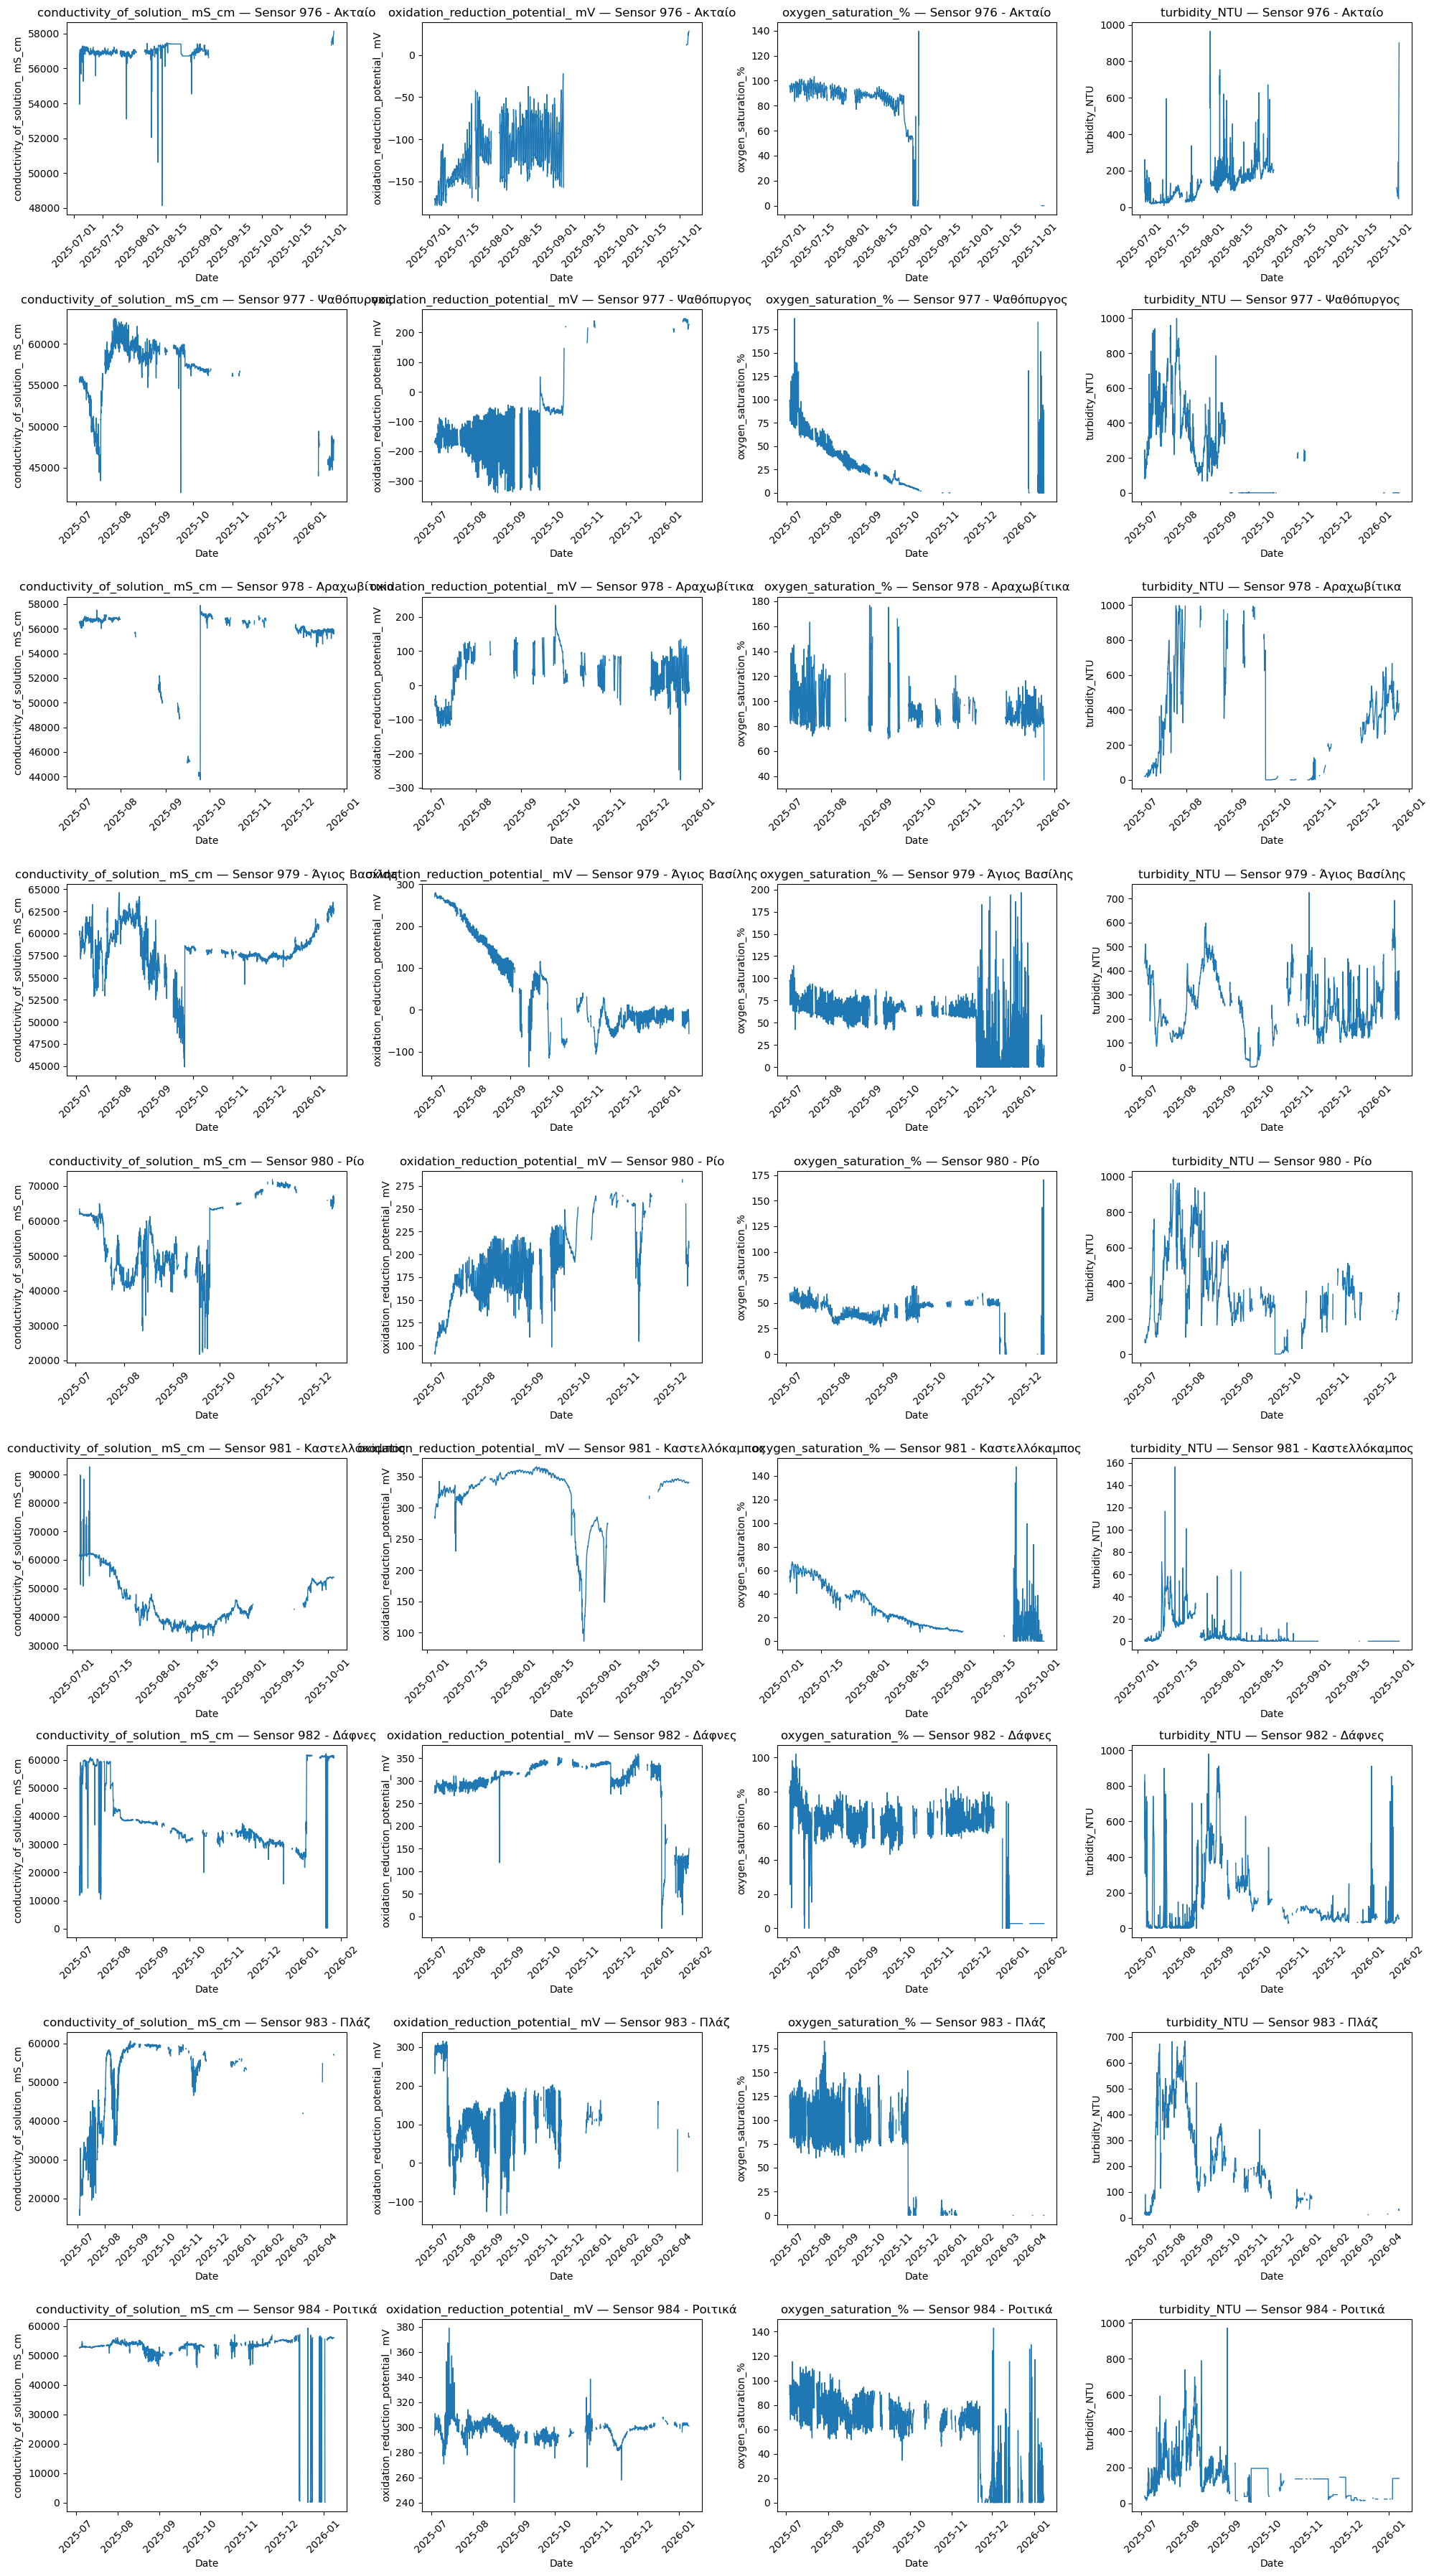

In [28]:
plot_sensors(sensor_ids= sorted(list(df['sensor_id'].unique())),metrics=MODEL_FEATURES, df= df_model,max_gap='24h')

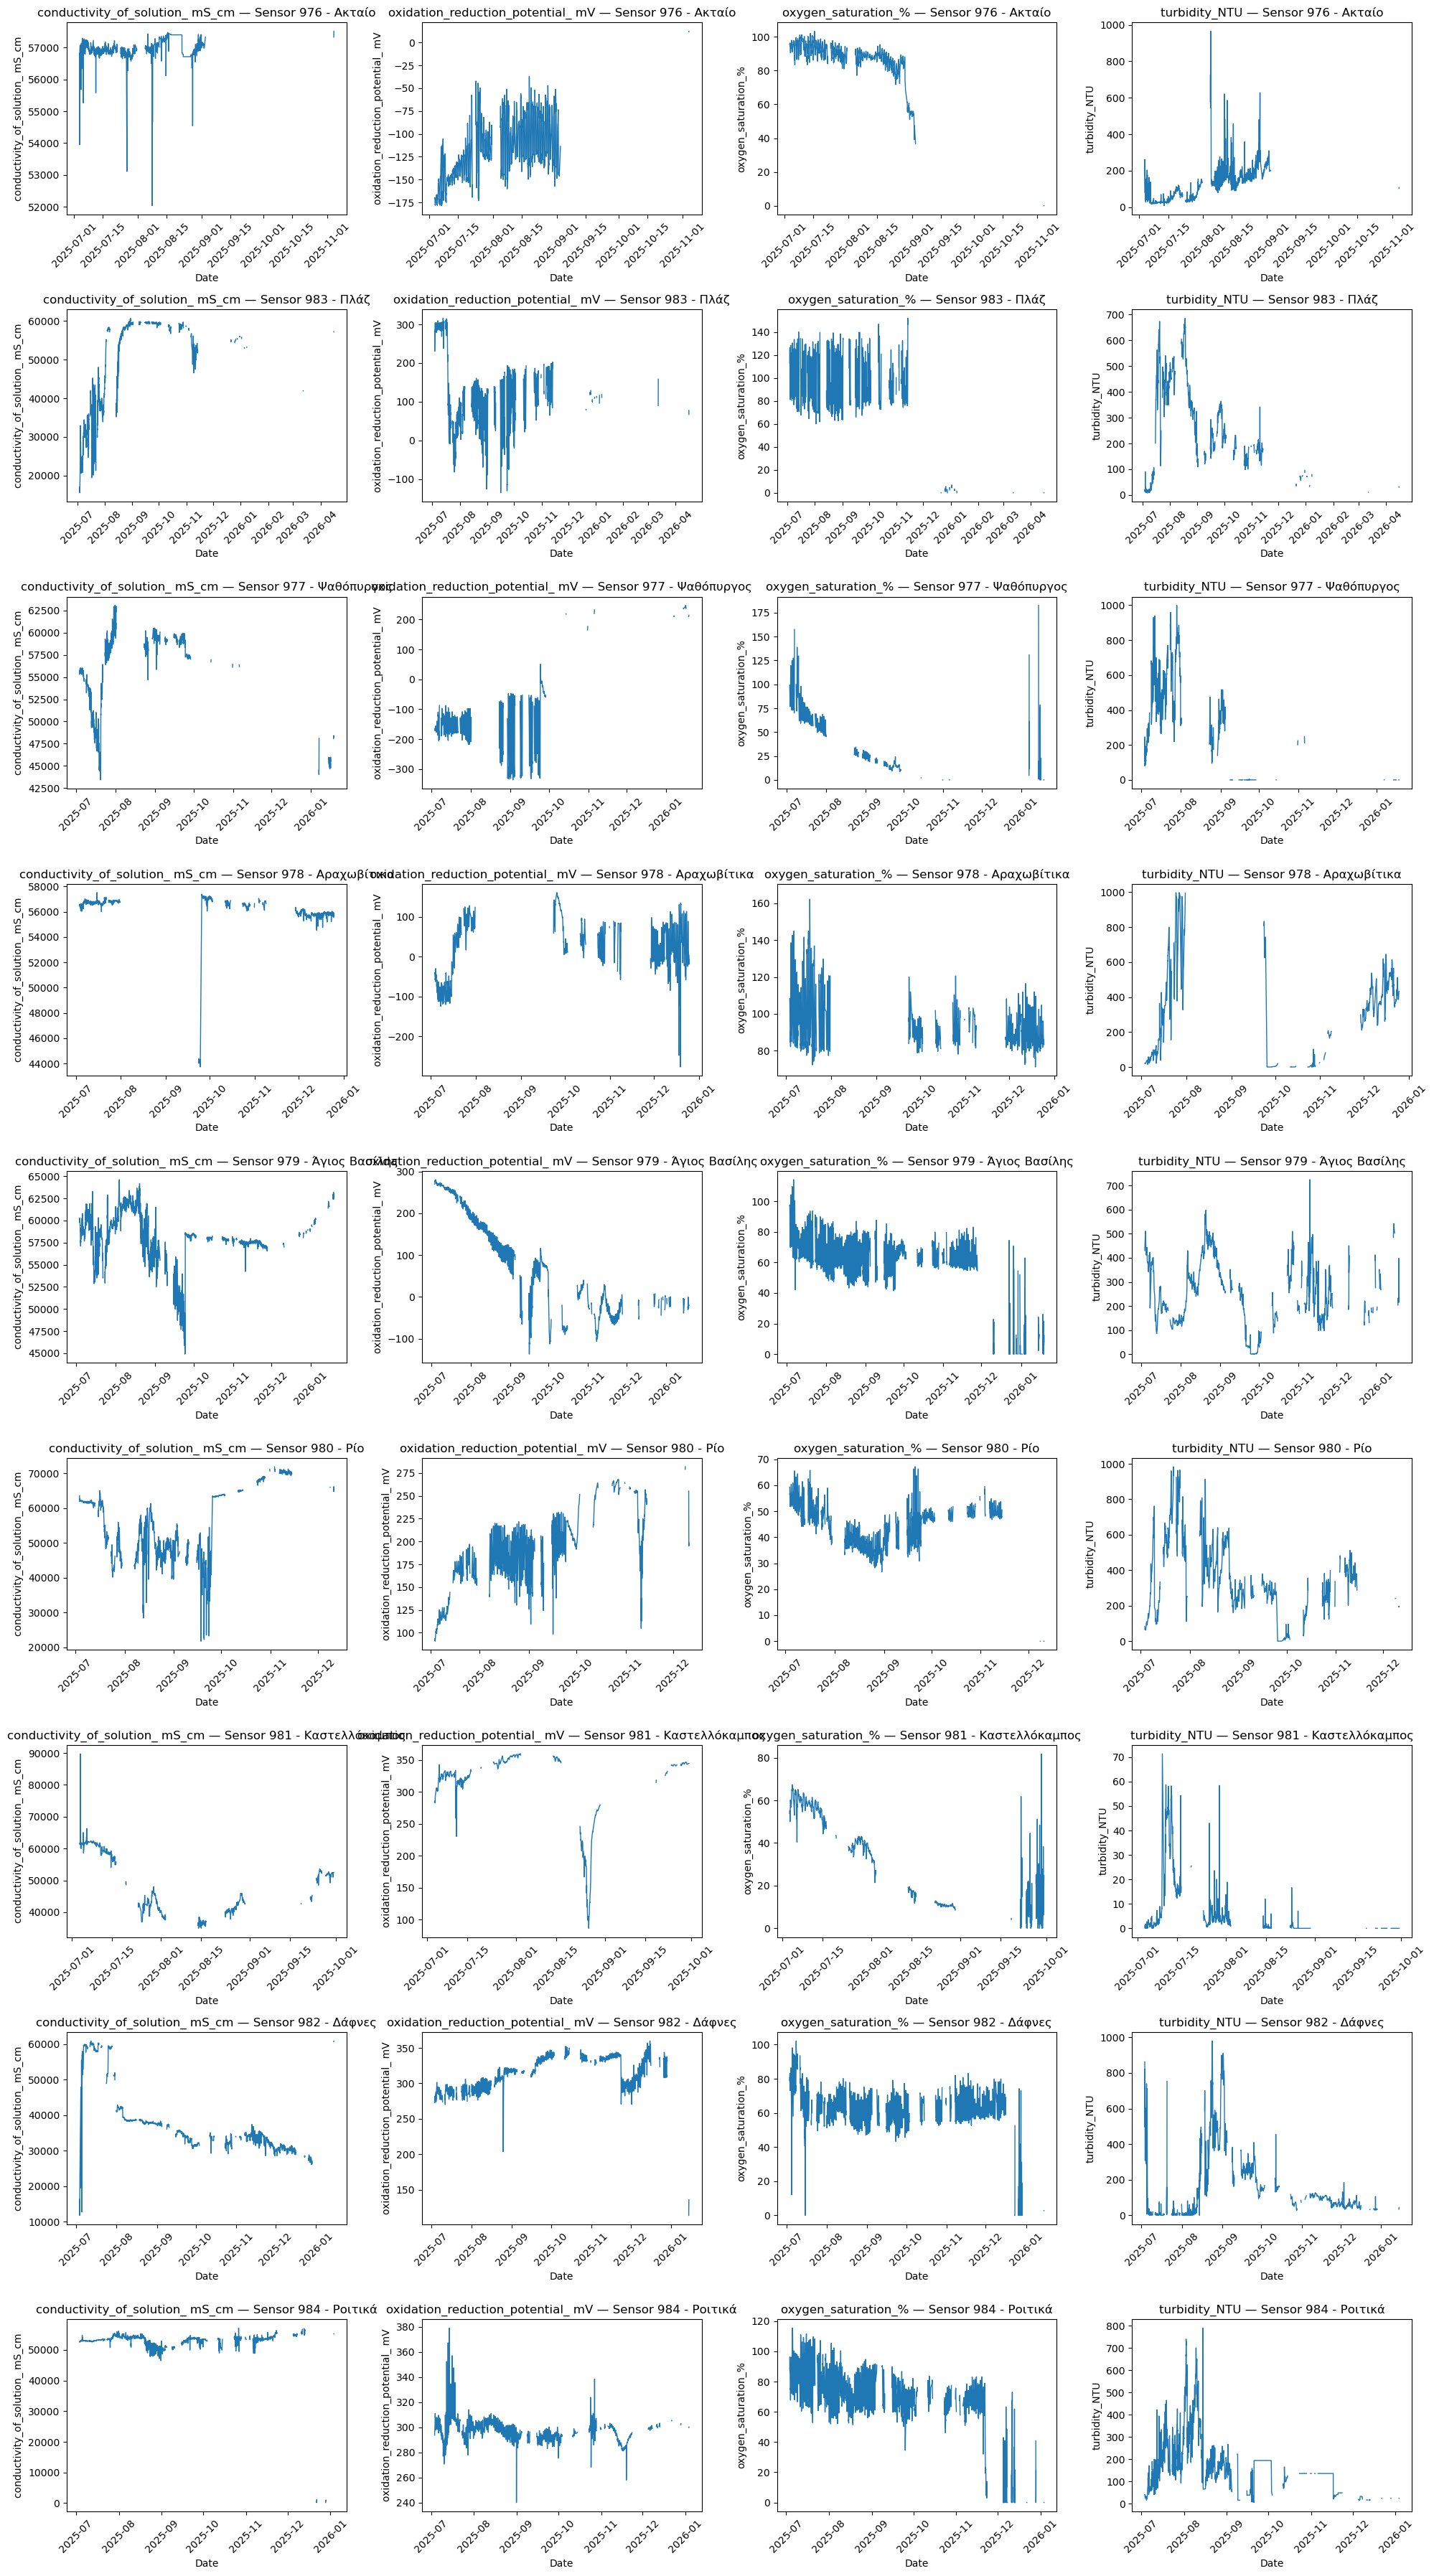

In [29]:
plot_sensors(list(df['sensor_id'].unique()),metrics=MODEL_FEATURES, df= df_model_strict,max_gap='24h')

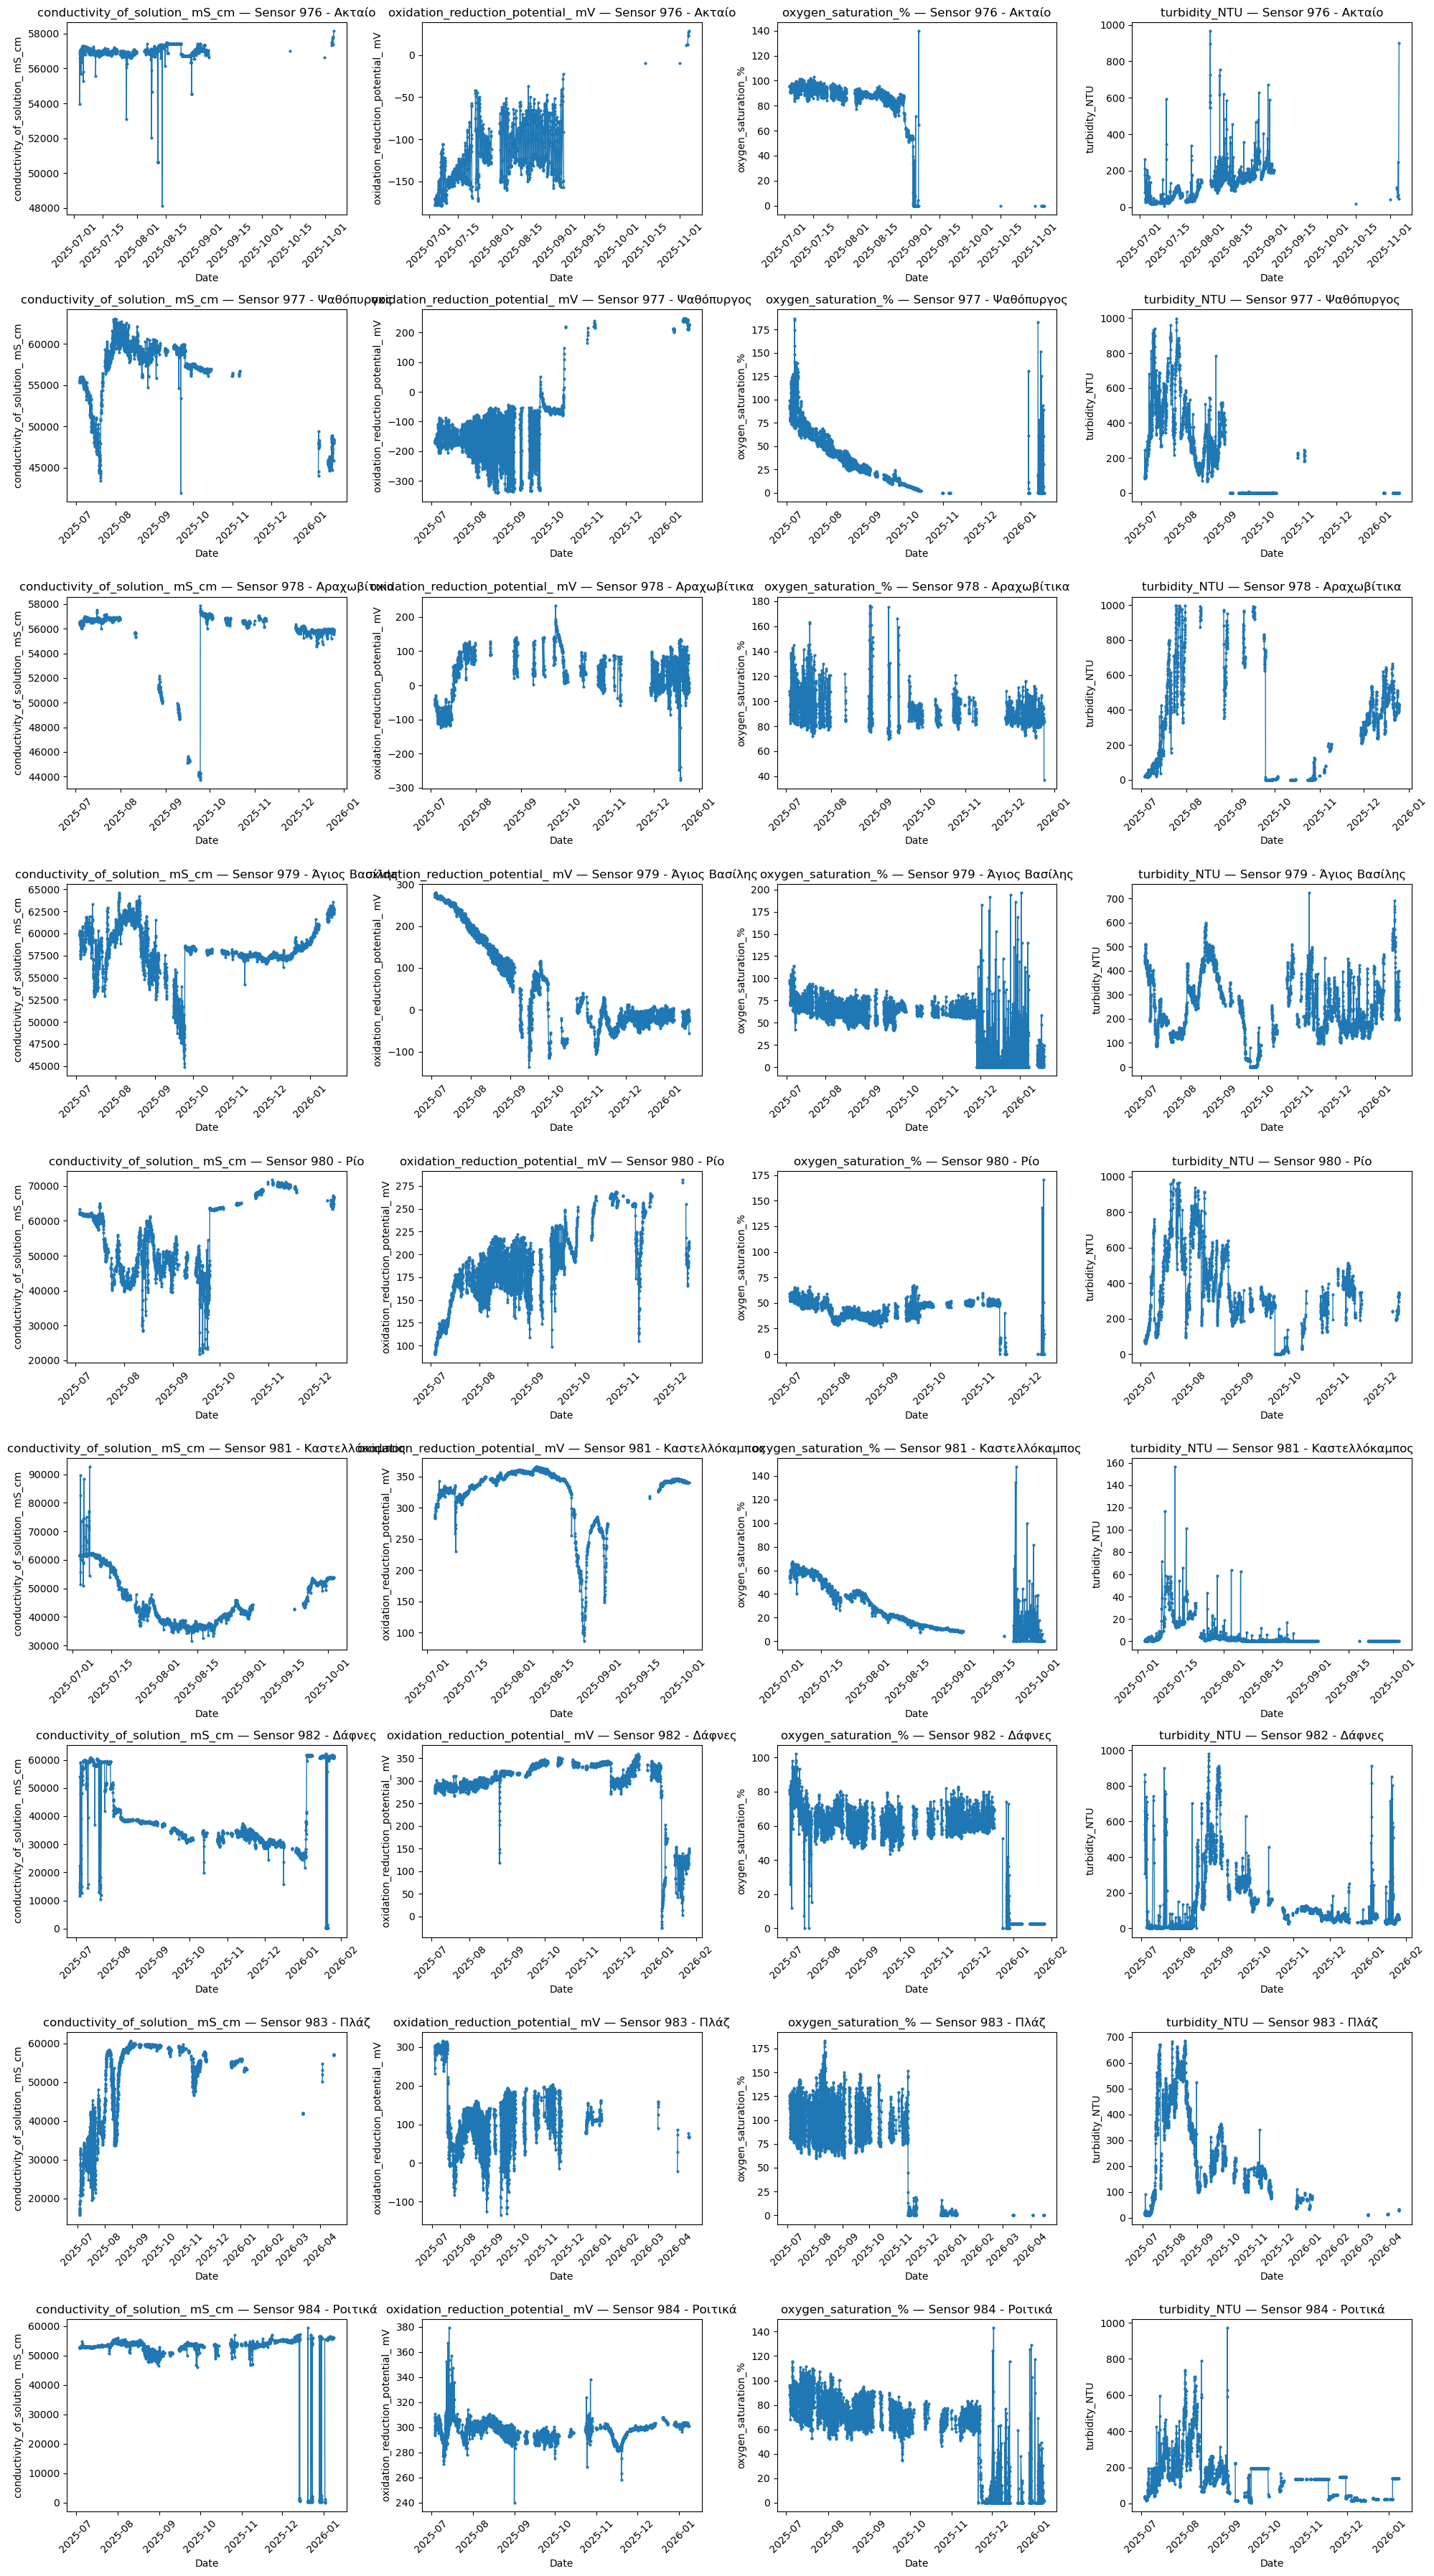

In [30]:
plot_sensors(
    sensor_ids=sorted(df_model["sensor_id"].unique()),
    metrics=MODEL_FEATURES,
    df=df_model,
    max_gap="24h",
    show_points=True
)

In [31]:
len(df_model)

21206

In [32]:
len(df_model_strict)

16260

In [33]:
print(
    "Number of detected conductivity-glitch intervals:",
    len(conductivity_glitch_intervals)
)

print(
    "Total conductivity readings invalidated:",
    int(df_clean["conductivity_transient_glitch"].sum())
)

display(
    conductivity_glitch_intervals.sort_values(
        [SENSOR_COL, "start_time"]
    )
)

Number of detected conductivity-glitch intervals: 44
Total conductivity readings invalidated: 64


,sensor_id,conductivity_drop_sequence_id,start_time,end_time,readings,baseline_conductivity,minimum_conductivity,maximum_conductivity,duration_hours,percentage_drop
0,976,2.0,2025-09-22 01:00:00,2025-09-22 01:00:00,1,56200.470,7542.16,7542.16,0.0,86.579899
1,976,4.0,2025-12-03 10:00:00,2025-12-03 12:00:00,3,56928.380,1335.11,1335.11,2.0,97.654755
2,977,1.0,2025-09-21 23:00:00,2025-09-21 23:00:00,1,59334.790,1748.49,1748.49,0.0,97.053179
3,977,2.0,2025-09-24 11:00:00,2025-09-24 11:00:00,1,59260.935,1768.30,1768.30,0.0,97.016078
4,977,3.0,2026-01-18 10:00:00,2026-01-18 10:00:00,1,48125.665,350.11,350.11,0.0,99.272509
5,977,4.0,2026-01-19 10:00:00,2026-01-19 10:00:00,1,48181.080,2272.02,2272.02,0.0,95.284415
6,977,5.0,2026-01-20 00:00:00,2026-01-20 00:00:00,1,48123.950,538.05,538.05,0.0,98.881950
7,977,7.0,2026-01-21 05:00:00,2026-01-21 05:00:00,1,41832.320,993.92,993.92,0.0,97.624038
8,977,8.0,2026-01-21 07:00:00,2026-01-21 09:00:00,3,40023.630,2628.64,5537.29,2.0,93.432280
9,977,10.0,2026-01-25 22:00:00,2026-01-25 22:00:00,1,48254.045,258.93,258.93,0.0,99.463402


In [34]:
conductivity_glitch_summary = (
    conductivity_glitch_intervals
    .groupby(SENSOR_COL)
    .agg(
        detected_intervals=(
            "conductivity_drop_sequence_id",
            "nunique"
        ),
        readings_removed=(
            "readings",
            "sum"
        ),
        median_percentage_drop=(
            "percentage_drop",
            "median"
        ),
        maximum_percentage_drop=(
            "percentage_drop",
            "max"
        )
    )
    .sort_values(
        "readings_removed",
        ascending=False
    )
)

display(
    conductivity_glitch_summary.round(2)
)

,detected_intervals,readings_removed,median_percentage_drop,maximum_percentage_drop
sensor_id,,,,
982,29,44,95.04,99.50
977,8,10,97.34,99.46
984,4,5,96.49,98.91
976,2,4,92.12,97.65
980,1,1,75.48,75.48


In [35]:
conductivity_inspection = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .copy()
)

conductivity_inspection["previous_conductivity"] = (
    conductivity_inspection
    .groupby(SENSOR_COL)["conductivity_original"]
    .shift(1)
)

conductivity_inspection["next_conductivity"] = (
    conductivity_inspection
    .groupby(SENSOR_COL)["conductivity_original"]
    .shift(-1)
)

conductivity_inspection = conductivity_inspection.loc[
    conductivity_inspection[
        "conductivity_transient_glitch"
    ],
    [
        SENSOR_COL,
        TIME_COL,
        "previous_conductivity",
        "conductivity_original",
        "next_conductivity",
        "conductivity_baseline_24h",
        "conductivity_drop_sequence_id"
    ]
]

conductivity_inspection["drop_percentage"] = (
    100
    * (
        conductivity_inspection[
            "conductivity_baseline_24h"
        ]
        - conductivity_inspection[
            "conductivity_original"
        ]
    )
    / conductivity_inspection[
        "conductivity_baseline_24h"
    ]
)

display(
    conductivity_inspection
    .sort_values([SENSOR_COL, TIME_COL])
    .round(2)
)

,sensor_id,date_insert,previous_conductivity,conductivity_original,next_conductivity,conductivity_baseline_24h,conductivity_drop_sequence_id,drop_percentage
1559,976,2025-09-22 01:00:00,56084.72,7542.16,55991.80,56200.47,2.0,86.58
2299,976,2025-12-03 10:00:00,56873.67,1335.11,1335.11,56928.38,4.0,97.65
2300,976,2025-12-03 11:00:00,1335.11,1335.11,1335.11,56928.38,4.0,97.65
2301,976,2025-12-03 12:00:00,1335.11,1335.11,56865.34,56909.74,4.0,97.65
4251,977,2025-09-21 23:00:00,59334.04,1748.49,59391.52,59334.79,1.0,97.05
...,...,...,...,...,...,...,...,...
30757,984,2025-07-14 01:00:00,53034.56,2098.56,53009.38,52872.98,1.0,96.03
33549,984,2025-12-14 01:00:00,56566.86,1682.72,57226.93,55143.02,3.0,96.95
33952,984,2025-12-30 20:00:00,56292.92,607.56,1500.23,55813.97,13.0,98.91
33953,984,2025-12-30 21:00:00,607.56,1500.23,56158.65,55813.97,13.0,97.31


In [36]:
# Number of usable observations per sensor
df_model.groupby(SENSOR_COL).size().sort_values()

sensor_id
976    1257
981    1631
978    1749
977    2208
980    2227
983    2523
984    2940
982    3181
979    3490
dtype: int64

In [37]:
# Confirm that the four model features are complete
df_model[MODEL_FEATURES].isna().sum()

conductivity_of_solution_ mS_cm      0
oxidation_reduction_potential_ mV    0
oxygen_saturation_%                  0
turbidity_NTU                        0
dtype: int64

In [38]:
# Examine the remaining very low oxygen readings
(
    df_model[df_model[OXYGEN_COL] < 5]
    .groupby(SENSOR_COL)
    .size()
    .sort_values(ascending=False)
)

sensor_id
979    607
982    491
984    289
983    244
977    187
981     98
976     52
980     44
dtype: int64

#### FINAL CHECKS

In [39]:
# No missing modelling measurements
display(df_model[MODEL_FEATURES].isna().sum())

conductivity_of_solution_ mS_cm      0
oxidation_reduction_potential_ mV    0
oxygen_saturation_%                  0
turbidity_NTU                        0
dtype: int64

In [40]:
# No duplicate sensor timestamps
duplicate_count = df_model.duplicated(
    subset=[SENSOR_COL, TIME_COL]
).sum()

print("Duplicate sensor timestamps:", duplicate_count)

Duplicate sensor timestamps: 0


In [41]:
# Number of retained observations per sensor
display(
    df_model
    .groupby(SENSOR_COL)
    .size()
    .rename("observations")
    .sort_values()
)

sensor_id
976    1257
981    1631
978    1749
977    2208
980    2227
983    2523
984    2940
982    3181
979    3490
Name: observations, dtype: int64

In [43]:
# Date coverage per sensor
display(
    df_model
    .groupby(SENSOR_COL)
    .agg(
        observations=(TIME_COL, "size"),
        first_timestamp=(TIME_COL, "min"),
        last_timestamp=(TIME_COL, "max")
    )
)

,observations,first_timestamp,last_timestamp
sensor_id,,,
976,1257,2025-07-03 15:00:00,2025-11-05 09:00:00
977,2208,2025-07-03 15:00:00,2026-01-19 08:00:00
978,1749,2025-07-03 15:00:00,2025-12-25 03:00:00
979,3490,2025-07-03 15:00:00,2026-04-11 09:00:00
980,2227,2025-07-03 15:00:00,2025-12-12 17:00:00
981,1631,2025-07-03 15:00:00,2025-10-03 03:00:00
982,3181,2025-07-03 15:00:00,2026-01-26 02:00:00
983,2523,2025-07-03 15:00:00,2026-04-16 06:00:00
984,2940,2025-07-03 15:00:00,2026-01-08 11:00:00


In [44]:
cleaning_summary = pd.Series({
    "Sentinel values": sum(
        df_clean[f"{column}__sentinel_invalid"].sum()
        for column in CLEANED_FEATURES
    ),
    "Hard-limit violations": sum(
        df_clean[f"{column}__hard_limit_invalid"].sum()
        for column in CLEANED_FEATURES
    ),
    "Persistent near-zero oxygen": (
        df_clean["oxygen_persistent_near_zero"].sum()
    ),
    "Transient conductivity glitches": (
        df_clean["conductivity_transient_glitch"].sum()
    ),
    "Additional conductivity collapses": (
        df_clean["conductivity_local_collapse"].sum()
    ),
    "Isolated turbidity spikes": (
        df_clean["isolated_turbidity_spike"].sum()
    )
}).astype(int)

display(cleaning_summary)

Sentinel values                       615
Hard-limit violations                2129
Persistent near-zero oxygen          9850
Transient conductivity glitches        64
Additional conductivity collapses      75
Isolated turbidity spikes             186
dtype: int64

In [45]:
cleaning_retention_summary = pd.Series({
    "Original rows": len(df_raw),
    "Final modelling rows": len(df_model),
    "Rows not available for modelling": len(df_raw) - len(df_model),
    "Retention percentage": 100 * len(df_model) / len(df_raw)
})

display(cleaning_retention_summary.round(2))

Original rows                       34146.0
Final modelling rows                21206.0
Rows not available for modelling    12940.0
Retention percentage                   62.1
dtype: float64

In [46]:
oxygen_removal_by_sensor = (
    df_clean
    .groupby(SENSOR_COL)
    .agg(
        total_clean_rows=(TIME_COL, "size"),
        persistent_near_zero_oxygen=(
            "oxygen_persistent_near_zero",
            "sum"
        )
    )
)

oxygen_removal_by_sensor["percentage_flagged"] = (
    100
    * oxygen_removal_by_sensor["persistent_near_zero_oxygen"]
    / oxygen_removal_by_sensor["total_clean_rows"]
)

display(
    oxygen_removal_by_sensor
    .sort_values("percentage_flagged", ascending=False)
    .round(2)
)

,total_clean_rows,persistent_near_zero_oxygen,percentage_flagged
sensor_id,,,
983,6366,3744,58.81
976,2607,1164,44.65
977,4084,1747,42.78
979,6073,2352,38.73
984,3627,544,15.00
982,3809,225,5.91
981,1757,74,4.21
978,2908,0,0.00
980,2915,0,0.00


In [47]:
coverage_summary = (
    df_model
    .groupby(SENSOR_COL)
    .agg(
        observations=(TIME_COL, "size"),
        first_timestamp=(TIME_COL, "min"),
        last_timestamp=(TIME_COL, "max")
    )
)

coverage_summary["expected_hourly_observations"] = (
    (
        coverage_summary["last_timestamp"]
        - coverage_summary["first_timestamp"]
    ).dt.total_seconds() / 3600
    + 1
)

coverage_summary["hourly_coverage_%"] = (
    100
    * coverage_summary["observations"]
    / coverage_summary["expected_hourly_observations"]
)

display(coverage_summary.round(2))

,observations,first_timestamp,last_timestamp,expected_hourly_observations,hourly_coverage_%
sensor_id,,,,,
976,1257,2025-07-03 15:00:00,2025-11-05 09:00:00,2995.0,41.97
977,2208,2025-07-03 15:00:00,2026-01-19 08:00:00,4794.0,46.06
978,1749,2025-07-03 15:00:00,2025-12-25 03:00:00,4189.0,41.75
979,3490,2025-07-03 15:00:00,2026-04-11 09:00:00,6763.0,51.60
980,2227,2025-07-03 15:00:00,2025-12-12 17:00:00,3891.0,57.23
981,1631,2025-07-03 15:00:00,2025-10-03 03:00:00,2197.0,74.24
982,3181,2025-07-03 15:00:00,2026-01-26 02:00:00,4956.0,64.18
983,2523,2025-07-03 15:00:00,2026-04-16 06:00:00,6880.0,36.67
984,2940,2025-07-03 15:00:00,2026-01-08 11:00:00,4533.0,64.86
